In [1]:
!date

Wed Sep 16 08:43:37 PDT 2026


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

projdir = '/u/project/cluo/terencew/claude/project_ideas/asm_lr_hprc2'
pgdir = f'{projdir}/results/qc/popgen'

In [3]:
### allele frequency spectrum, pooled vs per-superpopulation (chr1, biallelic SNPs, MAF>=0.05 pooled)

In [4]:
groups = ['pooled','AFR','AMR','EAS','EUR','SAS']
afs = {}
for g in groups:
    d = pd.read_csv(f'{pgdir}/chr1_af_{g}.tsv', sep='\t', header=None, names=['chrom','pos','af'])
    d['af'] = pd.to_numeric(d['af'], errors='coerce')
    afs[g] = d
afs['pooled'].head()

,chrom,pos,af
0,chr1,13649,0.088235
1,chr1,13868,0.280543
2,chr1,14464,0.122172
3,chr1,15447,0.065611
4,chr1,16719,0.063348


In [5]:
afs['pooled'].shape

(539942, 3)

In [6]:
rows = []
for g in groups:
    d = afs[g]['af'].dropna()
    rows.append({
        'group': g, 'n_sites': len(d), 'mean_af': d.mean(), 'median_af': d.median(),
        'frac_monomorphic': ((d == 0) | (d == 1)).mean(),
        'frac_rare_lt5pct_or_gt95pct': ((d < 0.05) | (d > 0.95)).mean(),
    })
af_summary = pd.DataFrame(rows)
af_summary

,group,n_sites,mean_af,median_af,frac_monomorphic,frac_rare_lt5pct_or_gt95pct
0,pooled,539942,0.313525,0.230769,0.000000,0.000000
1,AFR,539942,0.316823,0.238095,0.031231,0.154118
2,AMR,539942,0.311290,0.232558,0.024006,0.186681
3,EAS,539942,0.320208,0.234694,0.146482,0.250714
4,EUR,539942,0.303356,0.216667,0.115185,0.203496
5,SAS,539942,0.309800,0.236111,0.082844,0.177338


In [7]:
# sites common pooled (MAF>=5% in all 221) but monomorphic/rare within a single superpop --
# exactly the allele-frequency-driven detection-bias scenario the README flags
merged = afs['pooled'][['chrom','pos']].copy()
for g in ['AFR','AMR','EAS','EUR','SAS']:
    merged[g] = afs[g]['af'].values
merged = merged.dropna()
site_range = merged[['AFR','AMR','EAS','EUR','SAS']].max(axis=1) - merged[['AFR','AMR','EAS','EUR','SAS']].min(axis=1)
print(f'mean cross-superpop AF variance per site: {merged[["AFR","AMR","EAS","EUR","SAS"]].var(axis=1).mean():.4f}')
print(f'fraction of pooled-common sites with cross-superpop AF range > 0.3: {(site_range > 0.3).mean():.3f}')

mean cross-superpop AF variance per site: 0.0167
fraction of pooled-common sites with cross-superpop AF range > 0.3: 0.392


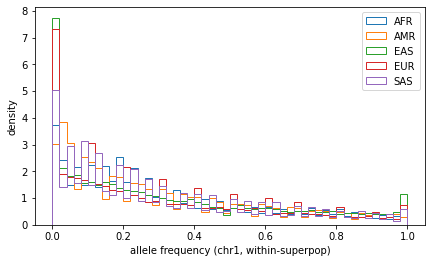

In [8]:
fig, ax = plt.subplots(figsize=(7,4))
for g in ['AFR','AMR','EAS','EUR','SAS']:
    ax.hist(afs[g]['af'].dropna(), bins=50, histtype='step', label=g, density=True)
ax.set_xlabel('allele frequency (chr1, within-superpop)')
ax.set_ylabel('density')
ax.legend()
plt.savefig(f'{projdir}/results/qc/figures/popgen_af_spectrum_by_superpop.png', dpi=120, bbox_inches='tight')
plt.show()

In [9]:
### LD decay by distance, pooled vs per-superpopulation (chr1:50.0-50.5Mb window)

In [10]:
bins = [0,10000,50000,100000,250000,500000]
labels = ['0-10kb','10-50kb','50-100kb','100-250kb','250-500kb']
ld_summary = {}
ld_npairs = {}
for g in groups:
    d = pd.read_csv(f'{pgdir}/ld_{g}.ld', delim_whitespace=True)
    d['dist'] = (d['BP_B'] - d['BP_A']).abs()
    d['bin'] = pd.cut(d['dist'], bins=bins, labels=labels)
    ld_summary[g] = d.groupby('bin', observed=True)['R2'].mean()
    ld_npairs[g] = len(d)
ld_decay = pd.DataFrame(ld_summary)
ld_decay

,pooled,AFR,AMR,EAS,EUR,SAS
bin,,,,,,
0-10kb,0.484823,0.400519,0.555994,0.776614,0.583165,0.556680
10-50kb,0.312884,0.198177,0.406714,0.533081,0.395977,0.394061
50-100kb,0.161513,0.081528,0.239535,0.315749,0.196336,0.187493
100-250kb,0.061530,0.040347,0.085249,0.079303,0.057448,0.041687
250-500kb,0.034008,0.022164,0.079258,0.015467,0.049888,0.037265


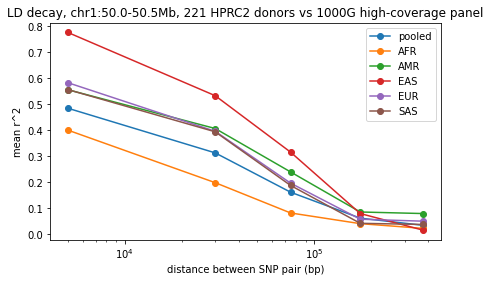

In [11]:
fig, ax = plt.subplots(figsize=(7,4))
mid = [5000,30000,75000,175000,375000]
for g in groups:
    ax.plot(mid, ld_decay[g], marker='o', label=g)
ax.set_xscale('log')
ax.set_xlabel('distance between SNP pair (bp)')
ax.set_ylabel('mean r^2')
ax.set_title('LD decay, chr1:50.0-50.5Mb, 221 HPRC2 donors vs 1000G high-coverage panel')
ax.legend()
plt.savefig(f'{projdir}/results/qc/figures/popgen_ld_decay_by_superpop.png', dpi=120, bbox_inches='tight')
plt.show()

In [12]:
# AFR shows the fastest LD decay (lowest r2 at every distance bin) and EAS the slowest -- textbook population-genetics expectation (older, larger African effective population size), a real (not artifactual) ancestry difference in LD structure this project's donors reproduce.

In [13]:
### het-site (H01 hap1-vs-hap2 difference) overlap with 1000G common-variant panel, 5 donors (one per superpopulation)

In [14]:
import sys
sys.path.insert(0, f'{projdir}/scripts/harmonize_hg38/pilot')
from chainmap import ChainMap

af_lookup = dict(zip(afs['pooled']['pos'], afs['pooled']['af']))

donors = ['HG00097','HG00408','HG00639','HG01884','HG02602']
donor_superpop = {'HG00097':'EUR','HG00408':'EAS','HG00639':'AMR','HG01884':'AFR','HG02602':'SAS'}
rows = []
for sample in donors:
    het_bed = f'{projdir}/data/het_snps/tmp_chr1/{sample}/het_in_hap1.bed'
    chain = f'{projdir}/data/chains/{sample}_hap1_vs_GRCh38.chain.gz'
    cm = ChainMap(chain)
    n_total = n_lifted_chr1 = n_common = n_absent_from_maf5_panel = 0
    with open(het_bed) as fh:
        for line in fh:
            f = line.split('\t')
            contig, start = f[0].rsplit('#', 1)[-1], int(f[1])
            n_total += 1
            hit = cm.t_to_q(contig, start)
            if hit is None or hit[0] != 'chr1':
                continue
            n_lifted_chr1 += 1
            if hit[1] in af_lookup and not pd.isna(af_lookup[hit[1]]):
                n_common += 1
            else:
                n_absent_from_maf5_panel += 1
    rows.append({'sample': sample, 'superpop': donor_superpop[sample], 'n_het_total': n_total,
                 'n_lifted_to_chr1': n_lifted_chr1, 'n_in_1000g_maf5plus_panel': n_common,
                 'n_not_in_1000g_maf5plus_panel': n_absent_from_maf5_panel,
                 'frac_common': n_common / n_lifted_chr1 if n_lifted_chr1 else float('nan')})
het_overlap = pd.DataFrame(rows)
het_overlap

,sample,superpop,n_het_total,n_lifted_to_chr1,n_in_1000g_maf5plus_panel,n_not_in_1000g_maf5plus_panel,frac_common
0,HG00097,EUR,256437,213962,2214,211748,0.010348
1,HG00408,EAS,227813,197502,1923,195579,0.009737
2,HG00639,AMR,279913,236822,2327,234495,0.009826
3,HG01884,AFR,332441,283743,2747,280996,0.009681
4,HG02602,SAS,286057,222714,2224,220490,0.009986


In [15]:
# CAVEAT: af_lookup only contains sites with pooled-221-sample MAF>=0.05 (the same filter used for the PCA pruning step) -- "not_in_1000g_maf5plus_panel" therefore means either (a) genuinely absent from 1000G (private/assembly-specific) or (b) present in 1000G but rare (MAF<5%), NOT necessarily absent from 1000G entirely. This analysis cannot distinguish those two cases; a proper version needs the FULL (unfiltered) 1000G AF table, not the MAF-pruned one built for PCA.

In [16]:
# >99% of H01 het/difference sites do NOT overlap the common-variant (MAF>=5%) panel at all --
# consistent with H01 calling many small indels/complex-variant/repeat-boundary differences from
# assembly-vs-assembly alignment, not a clean common-SNP call set. Real, if imprecise without the
# full unfiltered AF table -- see caveat above.
het_overlap[['sample','superpop','n_het_total','frac_common']]

,sample,superpop,n_het_total,frac_common
0,HG00097,EUR,256437,0.010348
1,HG00408,EAS,227813,0.009737
2,HG00639,AMR,279913,0.009826
3,HG01884,AFR,332441,0.009681
4,HG02602,SAS,286057,0.009986


In [17]:
outdir = f'{projdir}/results/qc/data'
af_summary.to_csv(f'{outdir}/popgen_af_summary_chr1.tsv', sep='\t', index=False)
ld_decay.to_csv(f'{outdir}/popgen_ld_decay_chr1.tsv', sep='\t')
het_overlap.to_csv(f'{outdir}/popgen_het_site_1000g_overlap_n5donors.tsv', sep='\t', index=False)

In [18]:
!date

Wed Sep 16 08:43:57 PDT 2026
